# AutoOpt: statistical analysis

Regenerates every number in the Probability and Statistics report from the run
data. Nothing here is typed in by hand; each cell calls the same functions the
`autoopt analyze` command uses, so the notebook and the report cannot disagree.

Sections follow the BMAT202L modules in order, so a result can be cited by the
module it belongs to.

**Two datasets.** `master.csv` is the unconstrained run and answers *what does
the system achieve*, which is what the Compiler Design submission reports.
`budgeted.csv` caps how many states each method may expand, so the methods are
compared at equal effort; that is the one the statistics use. Without the cap the
three plateau-crossing methods reach an identical result on every program and
`method` stops being a usable factor.

In [1]:
import warnings

import pandas as pd

from autoopt import stats
from autoopt.stats import analysis as stats_analysis
from autoopt.figures import THEMES, rc_params, statistical as statfigs

# After the autoopt imports, not before. The figures package selects Agg so it
# can render to file without a display, and a plot drawn under Agg never reaches
# the notebook. This puts the backend back.
%matplotlib inline
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

THEME = THEMES["dark"]
plt.rcParams.update(rc_params(THEME))

In [2]:
BUDGET = 10   # tightest budget where all six methods are still distinguishable

dataset = stats.load("../data/runs/budgeted.csv")
capability = stats.load("../data/runs/master.csv")

print("budgeted   ", dataset.describe())
print("unconstrained", capability.describe())

frame = dataset.at_budget(BUDGET)
result = stats_analysis.run(dataset, BUDGET)
print(f"\nanalysing {len(frame):,} runs at node budget {BUDGET}")

budgeted    9,000 runs, 500 programs, 6 methods, budgets [np.int64(6), np.int64(10), np.int64(16)]
unconstrained 3,000 runs, 500 programs, 6 methods, budgets [np.int64(0)]



analysing 3,000 runs at node budget 10


## Why the budgeted run exists

The unconstrained run gives the system's best result, but it cannot support a
comparison between methods. Greedy stops after about four state expansions while
A* uses ninety-six, so any difference between them measures how hard each tried
rather than how well it chose. Capping the budget makes the comparison fair.

The cell below shows what happens without the cap.

In [3]:
unconstrained = capability.frame.groupby("method", observed=True)["cost_reduction"]
comparison = pd.DataFrame({
    "unconstrained": unconstrained.mean(),
    "distinct final programs": capability.frame.groupby("method", observed=True)["cost_after"].nunique(),
}).join(
    frame.groupby("method", observed=True)["cost_reduction"].mean().rename(f"budget {BUDGET}")
).sort_values(f"budget {BUDGET}", ascending=False)
comparison

,unconstrained,distinct final programs,budget 10
method,,,
astar,0.3675,42,0.3294
hill_climbing,0.3675,42,0.3090
simulated_annealing,0.3675,42,0.2494
random_baseline,0.2152,31,0.2079
fixed_pipeline,0.2150,31,0.2058
greedy,0.2150,31,0.2058


## M1: descriptive statistics

In [4]:
m1 = result.section("M1")
m1.tables["overall"]

,response,n,mean,median,sd,IQR,skewness,kurtosis,shape
0,cost reduction,3000,0.2512,0.2000,0.2234,0.2622,1.2291,0.8446,strongly right skewed
1,transformations accepted,3000,5.4063,5.0000,3.2119,6.0000,0.2323,-1.3240,roughly symmetric
2,steps to convergence,3000,12.6880,6.0000,19.9125,9.0000,3.2171,10.2728,strongly right skewed
3,states expanded,3000,6.4230,6.0000,3.0446,6.0000,-0.0175,-1.4821,roughly symmetric
4,instructions removed,3000,2.1317,2.0000,1.9030,3.0000,0.6442,-0.4660,right skewed
5,verification pass rate,3000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,"constant, no variation"


In [5]:
m1.tables["by_method"]

,method,n,mean,median,sd,min,max,skew
0,astar,500,0.3294,0.2971,0.2557,0.0290,0.9338,1.1129
1,hill_climbing,500,0.3090,0.3000,0.2270,0.0290,0.8675,0.8936
2,simulated_annealing,500,0.2494,0.1986,0.1816,0.0290,0.6690,0.5644
3,random_baseline,500,0.2079,0.1260,0.2143,0.0000,0.7936,1.5347
4,fixed_pipeline,500,0.2058,0.1260,0.2104,0.0000,0.7936,1.5331
5,greedy,500,0.2058,0.1260,0.2104,0.0000,0.7936,1.5331


findfont: Failed to find font weight 500, now using 600.


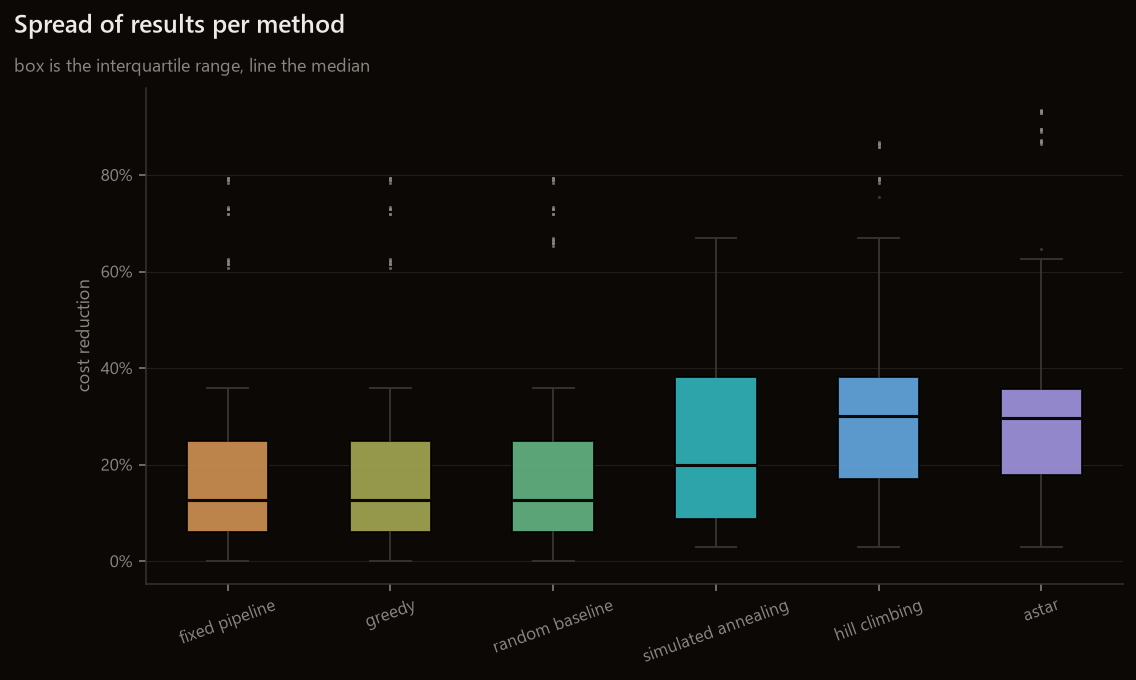

In [6]:
fig = statfigs.method_boxplot(frame, THEME); plt.show()

Every response is right skewed, so the mean sits above the typical program. That
is why the normality assumption is checked in M6 rather than assumed, and why a
non-parametric test is reported next to the t test.

## M2: random variables and joint distributions

The acceptance rule is a joint distribution without anything being invented.
`V = 1` when verification does not refute a proposal, `C = 1` when it lowers
cost, and the agent accepts exactly when both hold.

In [7]:
m2 = result.section("M2")
joint = stats.randomvars.joint_table(frame)
print(joint.joint.to_string())
print()
print(f"P(V=1)     = {joint.p_verified:.4f}   <- Verification Pass Rate, a marginal")
print(f"P(C=1|V=1) = {joint.p_cheaper_given_verified:.4f}   <- Acceptance Rate, a conditional")
print(f"P(V=1,C=1) = {joint.p_accept:.4f}   <- the acceptance rule itself")

                C=0 (no gain)  C=1 (cheaper)
V=0 (refuted)          0.0000         0.0000
V=1 (verified)         0.5941         0.4059

P(V=1)     = 1.0000   <- Verification Pass Rate, a marginal
P(C=1|V=1) = 0.4059   <- Acceptance Rate, a conditional
P(V=1,C=1) = 0.4059   <- the acceptance rule itself


In [8]:
m2.tables["expectation_variance"]

,variable,p,E[X],Var[X]
0,V (verified),1.0000,1.0000,0.0000
1,C (cheaper),0.4059,0.4059,0.2411
2,V AND C (accepted),0.4059,0.4059,0.2411


In [9]:
print(stats.randomvars.moments(frame["cost_reduction"]).to_string(index=False))
print()
print(stats.randomvars.mgf(frame["cost_reduction"]).to_string(index=False))

     moment  value
       E[X] 0.2512
     E[X^2] 0.1130
     Var[X] 0.0499
E[(X-mu)^3] 0.0137
E[(X-mu)^4] 0.0096

      t   M(t)
-1.0000 0.7958
-0.5000 0.8872
 0.5000 1.1412
 1.0000 1.3211


## M3: correlation and regression

In [10]:
m3 = result.section("M3")
m3.tables["correlations"]

,x,y,pearson,p,spearman,strength,n
0,accepted,cost_reduction,0.6420,0.0000,0.7015,strong,3000
1,instructions_before,cost_reduction,-0.2993,0.0000,-0.2459,weak,3000
2,nodes_expanded,cost_reduction,0.6200,0.0000,0.6991,strong,3000


Program size drives both how much work there is to do and how much can be saved,
so the raw correlation between transformations accepted and cost reduction is
partly just size appearing twice. Partialling size out says how much survives.

In [11]:
partial = m3.values["partial_accepted_vs_reduction_controlling_size"]
print(f"r(accepted, reduction)              = {partial['r_xy']:+.4f}")
print(f"r with size partialled out          = {partial['partial']:+.4f}")
print(f"t = {partial['t']:.3f}, p = {partial['p_value']:.2e}, n = {partial['n']:,}")

r(accepted, reduction)              = +0.6420
r with size partialled out          = +0.8076
t = 74.977, p = 0.00e+00, n = 3,000


In [12]:
m3.tables["regression_coefficients"]

,term,coefficient,std_error,t,p_value
0,Intercept,0.8080,0.0224,36.1163,0.0000
1,C(category)[T.nested],-0.6080,0.0187,-32.5928,0.0000
2,C(category)[T.repeated],-0.4359,0.0174,-25.0985,0.0000
3,C(category)[T.dead_code],-0.4836,0.0122,-39.6564,0.0000
4,C(category)[T.loops],-0.7368,0.0225,-32.7478,0.0000
5,C(category)[T.conditional],-0.3733,0.0169,-22.0563,0.0000
6,C(category)[T.mixed],-0.4224,0.0200,-21.0741,0.0000
7,instructions_before,-0.0024,0.0048,-0.4914,0.6232
8,arithmetic_before,-0.0276,0.0154,-1.7927,0.0731
9,temps_before,0.0067,0.0195,0.3427,0.7318


In [13]:
reg = m3.values["regression"]
print(f"{reg['formula']}")
print(f"R^2 = {reg['r_squared']:.4f}, adjusted {reg['adjusted_r_squared']:.4f}")
print(f"F = {reg['f']:.1f}, p = {reg['f_p']:.3e}, n = {reg['n']:,}")
print(f"multicollinear: {reg['multicollinear']}   heteroscedastic: {reg['heteroscedastic']}")

cost_reduction ~ instructions_before + arithmetic_before + temps_before + exec_before + C(category)
R^2 = 0.8256, adjusted 0.8250
F = 1414.9, p = 0.000e+00, n = 3,000
multicollinear: True   heteroscedastic: True


findfont: Failed to find font weight 500, now using 600.


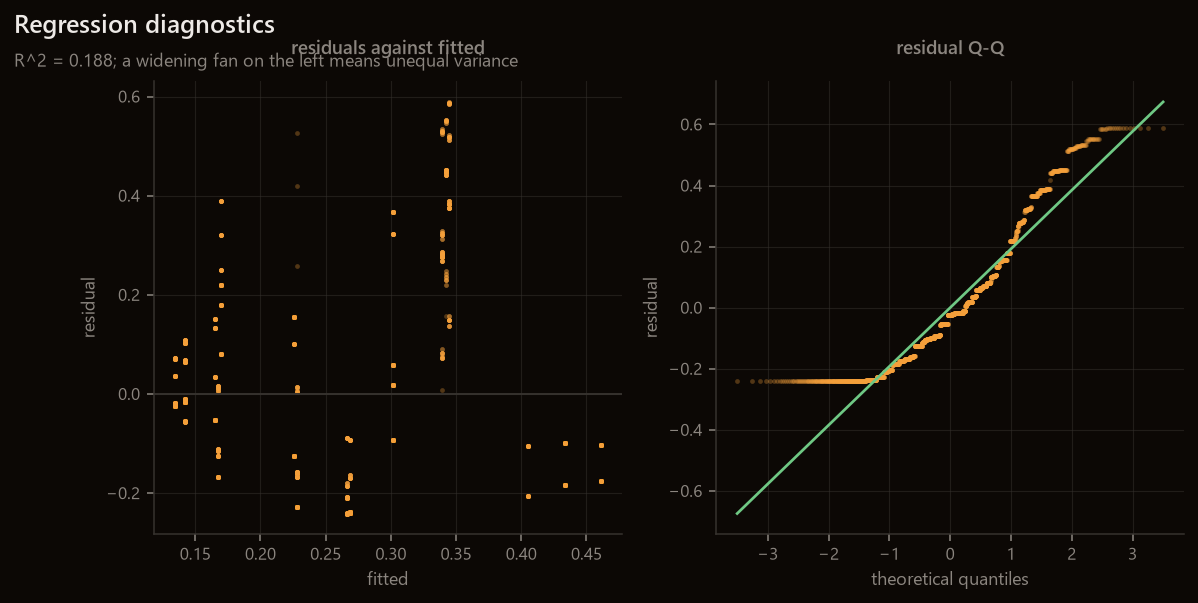

In [14]:
fig = statfigs.residual_diagnostics(frame, THEME); plt.show()

### Fitting the cost weights

Project 5 names four cost terms and gives no weights; the bootstrap used the ones
from Project 3 on the same handout. Regressing measured run time on the four
terms says what they are actually worth.

In [15]:
weights = m3.values["fitted_cost_weights"]
pd.DataFrame({
    "handout": weights["handout_weights"],
    "fitted from data": weights["fitted_weights"],
})

,handout,fitted from data
instructions,0.4000,0.1358
arithmetic,0.3000,0.3379
temporaries,0.2000,0.3955
execution,0.1000,0.1308


## M4: probability distributions and goodness of fit

In [16]:
m4 = result.section("M4")
m4.tables["continuous_cost_reduction"]

,family,AIC,BIC,log_likelihood,KS,KS p,chi2,chi2 p,GOF rejected
0,gamma,"-3,207.2620","-3,195.2492","1,605.6310",0.1914,0.0000,"1,042.9267",0.0000,True
1,weibull,"-2,722.3403","-2,710.3275","1,363.1701",0.1613,0.0000,859.8600,0.0000,True
2,exponential,"-2,287.0555","-2,281.0491","1,144.5277",0.0664,0.0000,654.4267,0.0000,True
3,normal,-477.3236,-465.3109,240.6618,0.1443,0.0000,"1,811.9000",0.0000,True
4,lognormal,"1,533.4302","1,545.4429",-764.7151,0.3407,0.0000,"4,378.1067",0.0000,True


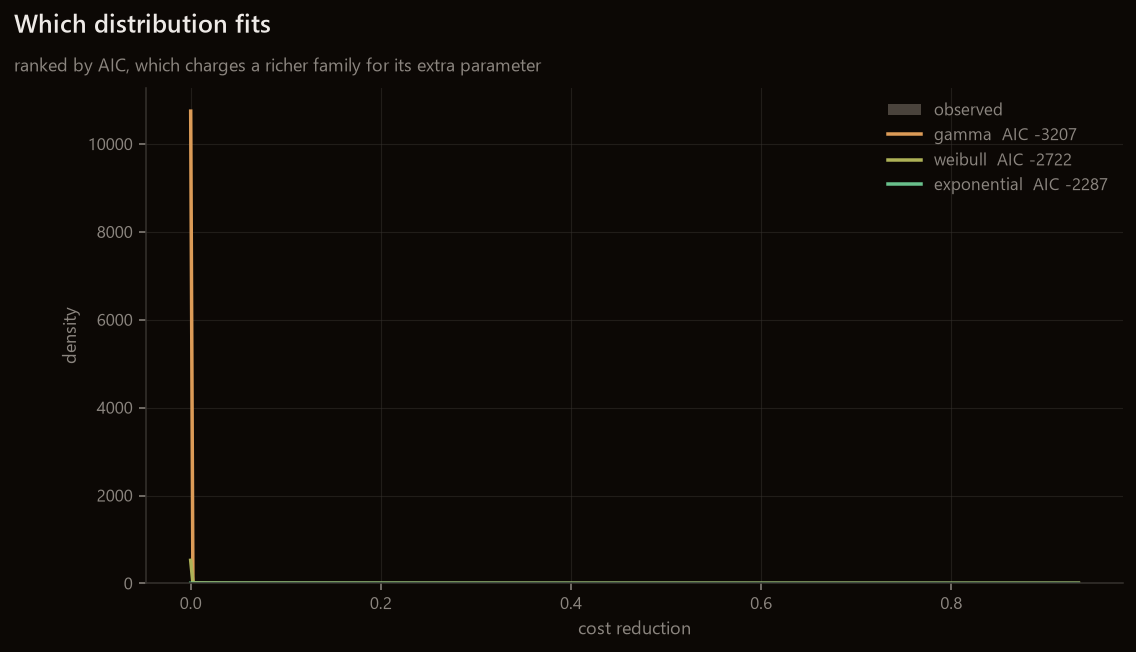

In [17]:
fig = statfigs.distribution_fit(frame, THEME); plt.show()

In [18]:
m4.tables["discrete_accepted"]

,family,chi2,dof,p_value,rejected_at_5pc
0,poisson,"5,830.8759",9,0.0000,True
1,binomial,"60,902.8625",8,0.0000,True
2,geometric,"4,702.7163",9,0.0000,True


Normal is fitted alongside the skewed families deliberately. Comparing them shows
whether assuming normality would have been safe, rather than leaving it as an
untested premise of the ANOVA.

## M5: hypothesis testing I

Each test states the null, the alternative, the critical value, the decision, and
which error the decision risks.

In [19]:
m5 = result.section("M5")
for key, test in m5.values.items():
    print(f"{test.name}")
    print(f"   H0: {test.null}")
    print(f"   H1: {test.alternative}")
    print(f"   statistic {test.statistic:.4f}, critical {test.critical_value:.4f}")
    print(f"   p = {test.p_value:.3e}  ->  {test.decision}")
    print(f"   risks {test.type_of_error_at_risk}")
    if test.note:
        print(f"   {test.note}")
    print()

Z test, verification pass rate vs 95%
   H0: p = 0.95
   H1: p != 0.95
   statistic 76.3596, critical 1.9600
   p = 0.000e+00  ->  reject H0 at alpha=0.05
   risks Type I (false positive)
   observed p_hat = 1.0000 from 110785/110785

Z test, false positive rate vs 1%
   H0: p = 0.01
   H1: p != 0.01
   statistic -5.5048, critical 1.9600
   p = 3.695e-08  ->  reject H0 at alpha=0.05
   risks Type I (false positive)
   observed p_hat = 0.0000 from 0/3000

Z test, share of runs beating the 30% target vs 50%
   H0: p = 0.5
   H1: p != 0.5
   statistic -19.1703, critical 1.9600
   p = 0.000e+00  ->  reject H0 at alpha=0.05
   risks Type I (false positive)
   observed p_hat = 0.3250 from 975/3000



## M6: hypothesis testing II and design of experiments

Assumptions first. A significant Levene means the equal variance assumption
fails and the F test below is optimistic, which is worth knowing before reading
it rather than after.

In [20]:
m6 = result.section("M6")
checks = m6.tables["assumptions_by_method"]
print(checks.to_string(index=False))
print()
print(f"Levene p = {m6.values['levene_p']:.3e}, equal variance: {m6.values['equal_variance']}")

              group   n  shapiro_W  shapiro_p  normal_at_5pc
              astar 500     0.8464     0.0000          False
     fixed_pipeline 500     0.7891     0.0000          False
             greedy 500     0.7891     0.0000          False
      hill_climbing 500     0.8973     0.0000          False
    random_baseline 500     0.7808     0.0000          False
simulated_annealing 500     0.9074     0.0000          False

Levene p = 2.498e-05, equal variance: False


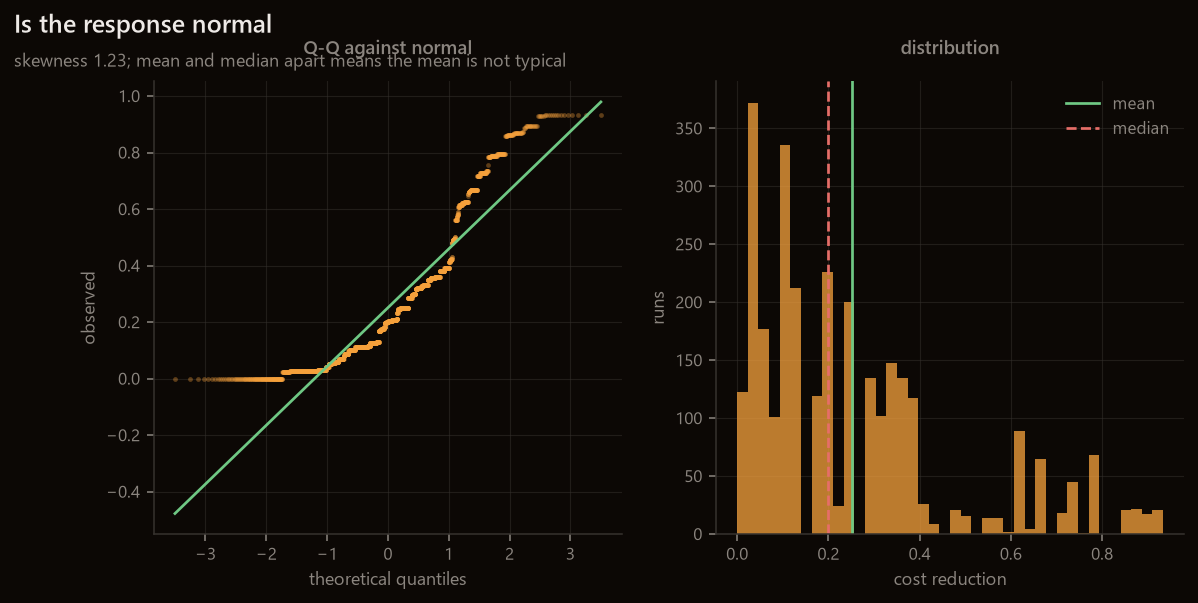

In [21]:
fig = statfigs.qq_plot(frame, THEME); plt.show()

### CRD: one-way ANOVA on category

In [22]:
m6.tables["crd_category"]

,source,sum_sq,df,F,PR(>F),partial_eta_sq
0,C(category),122.9398,6.0000,"2,299.2119",0.0000,0.8217
1,Residual,26.6728,"2,993.0000",NaN,NaN,0.5000


### RBD: two-way ANOVA, method as treatment and category as block

In [23]:
m6.tables["rbd_method_category"]

,source,sum_sq,df,F,PR(>F),partial_eta_sq
0,C(method),7.7328,5.0000,424.1673,0.0000,0.4176
1,C(category),122.9398,6.0000,"5,619.7045",0.0000,0.9193
2,C(method):C(category),8.1549,30.0000,74.5539,0.0000,0.4306
3,Residual,10.7851,"2,958.0000",NaN,NaN,0.5000


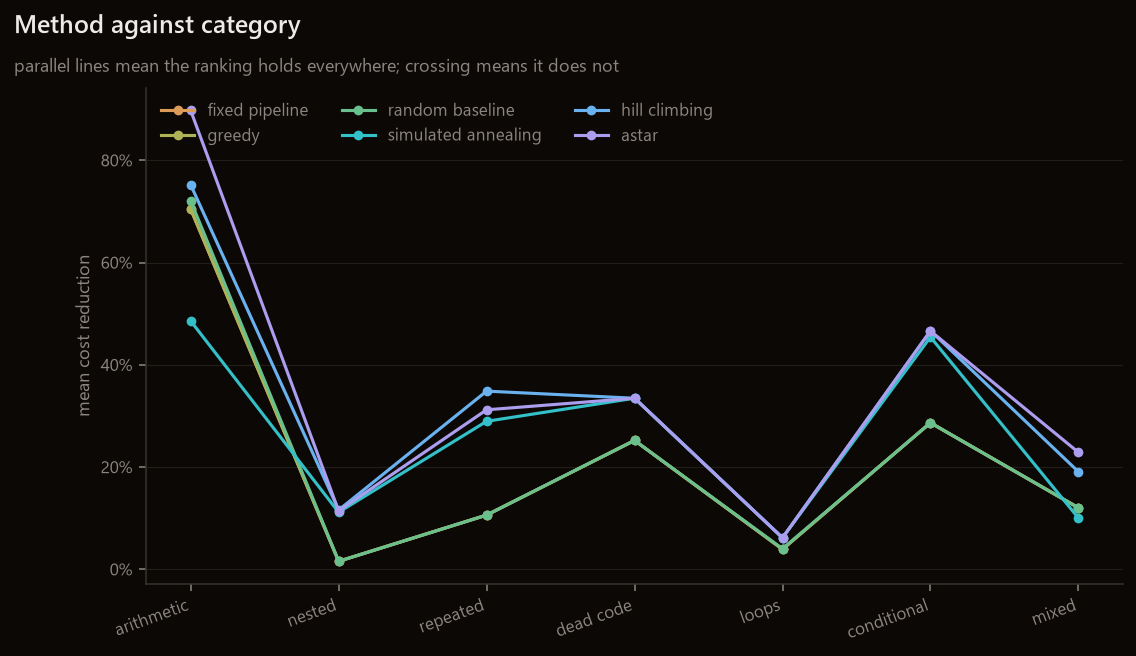

In [24]:
fig = statfigs.interaction_plot(frame, THEME); plt.show()

Lines that are not parallel mean the method ranking depends on the category, so
the main effect cannot be read on its own.

### Three-way ANOVA: method, category and size

Blocked on relative size. Blocking on absolute size instead leaves most cells of
the crossed design empty, and the saturated model is then rank deficient: every
effect comes back with a sum of squares of zero and p = 1, which looks like a
finding and is an artefact.

In [25]:
m6.tables["three_way"]

,source,sum_sq,df,F,PR(>F),partial_eta_sq
0,C(method),7.7328,5.0000,523.2242,0.0000,0.4802
1,C(category),122.9398,6.0000,"6,932.0885",0.0000,0.9363
2,C(relative_size),0.1567,3.0000,17.6747,0.0000,0.0184
3,C(method):C(category),8.1549,30.0000,91.9646,0.0000,0.4935
4,C(method):C(relative_size),0.1688,15.0000,3.8061,0.0000,0.0198
5,C(category):C(relative_size),1.3013,18.0000,24.4577,0.0000,0.1345
6,C(method):C(category):C(relative_size),0.7875,90.0000,2.9604,0.0000,0.0860
7,Residual,8.3709,"2,832.0000",NaN,NaN,0.5000


### The confound worth reporting

Absolute program size and category are almost perfectly confounded in this
corpus. Dead-code programs are always short and mixed ones always long, so
knowing the category tells you the stratum, and the crosstab below is nearly
diagonal. The Latin Square therefore blocks on size *relative to other programs
in the same category*, which is orthogonal to category by construction.

In [26]:
m6.tables["confounding_size_category"]

category,size_stratum,arithmetic,nested,repeated,dead_code,loops,conditional,mixed
0,small,228,360,180,360,0,0,0
1,medium,132,0,180,0,0,282,0
2,large,0,0,0,0,480,198,0
3,xlarge,0,0,0,0,0,0,600


### LSD: 4x4 Latin Square, replicated

In [27]:
m6.tables["latin_square_anova"]

,source,sum_sq,df,F,PR(>F),partial_eta_sq
0,C(method),0.2487,3.0000,13.7077,0.0000,0.2584
1,C(relative_size),0.0849,3.0000,4.6811,0.0040,0.1064
2,C(category),7.9122,3.0000,436.1382,0.0000,0.9173
3,Residual,0.7136,118.0000,NaN,NaN,0.5000


Replicated on purpose. A bare 4x4 gives sixteen observations and six residual
degrees of freedom, which reported method as non-significant at p = 0.62 -- a
property of the design, not of the data. With several runs per cell the same
design detects all three factors.

### Tukey HSD and homogeneous subsets

In [28]:
m6.tables["tukey_method"]

,group1,group2,meandiff,p-adj,lower,upper,reject
0,astar,fixed_pipeline,-0.1236,0.0000,-0.1629,-0.0844,True
1,astar,greedy,-0.1236,0.0000,-0.1629,-0.0844,True
2,astar,hill_climbing,-0.0204,0.6772,-0.0596,0.0189,False
3,astar,random_baseline,-0.1215,0.0000,-0.1608,-0.0823,True
4,astar,simulated_annealing,-0.0800,0.0000,-0.1193,-0.0407,True
5,fixed_pipeline,greedy,0.0000,1.0000,-0.0393,0.0393,False
6,fixed_pipeline,hill_climbing,0.1033,0.0000,0.0640,0.1425,True
7,fixed_pipeline,random_baseline,0.0021,1.0000,-0.0371,0.0414,False
8,fixed_pipeline,simulated_annealing,0.0436,0.0193,0.0044,0.0829,True
9,greedy,hill_climbing,0.1033,0.0000,0.0640,0.1425,True


In [29]:
for index, subset in enumerate(m6.values["homogeneous_subsets"], 1):
    print(f"group {index}: {', '.join(subset)}")
print()
print("Levels within a group are ones Tukey could not separate.")

group 1: astar, hill_climbing
group 2: simulated_annealing
group 3: random_baseline, fixed_pipeline, greedy

Levels within a group are ones Tukey could not separate.


### Method against budget

In [30]:
m6.tables["method_x_budget"]

node_budget,method,6,10,16
0,astar,0.2655,0.3294,0.3581
1,fixed_pipeline,0.1782,0.2058,0.2150
2,greedy,0.1782,0.2058,0.2150
3,hill_climbing,0.2326,0.3090,0.3543
4,random_baseline,0.1866,0.2079,0.2152
5,simulated_annealing,0.1716,0.2494,0.3401


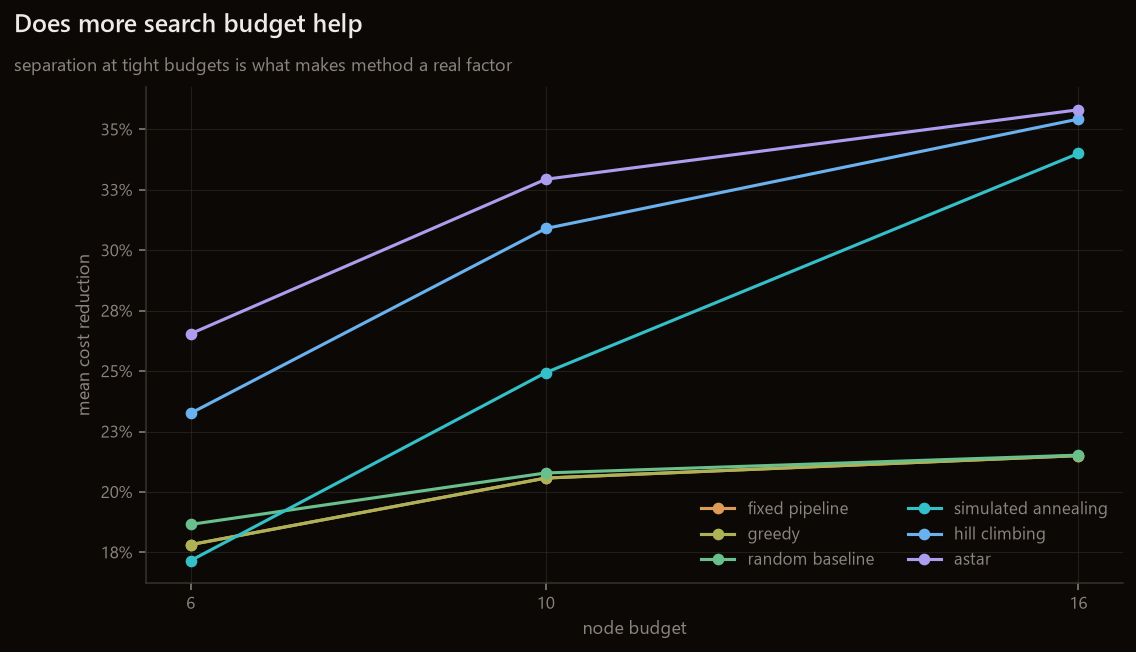

In [31]:
fig = statfigs.budget_interaction(dataset.frame, THEME); plt.show()

### Paired comparison, with a non-parametric backup

In [32]:
for key in ("paired_t_best_vs_worst", "wilcoxon_best_vs_worst", "f_test_variances"):
    test = m6.values[key]
    print(f"{test.name}")
    print(f"   statistic {test.statistic:.4f}, p = {test.p_value:.3e}  ->  {test.decision}")
    if test.effect_size is not None:
        print(f"   {test.effect_name} = {test.effect_size:.4f}")
    print()

paired t test, astar vs fixed_pipeline
   statistic 35.9670, p = 1.132e-140  ->  reject H0 at alpha=0.05
   Cohen's d (paired) = 1.6085

Wilcoxon signed rank, astar vs fixed_pipeline
   statistic 0.0000, p = 5.359e-76  ->  reject H0 at alpha=0.05

F test of variances, astar vs fixed_pipeline
   statistic 1.4768, p = 1.434e-05  ->  reject H0 at alpha=0.05



### Chi-square tests and power

In [33]:
for key in ("chi2_gof_applied_mix", "chi2_independence_category_plateau"):
    test = m6.values[key]
    print(f"{test.name}: chi2 = {test.statistic:.2f}, dof {test.dof}, p = {test.p_value:.3e}")
    print(f"   {test.decision}")
print()
power = m6.values["power_analysis"]
print(f"To detect f = {power['effect_size_f']} at alpha = {power['alpha']} with power "
      f"{power['target_power']}: {power['required_total_n']:.0f} runs total, "
      f"{power['required_per_group']:.0f} per method.")

chi-square goodness of fit, applied mix: chi2 = 11791.89, dof 7, p = 0.000e+00
   reject H0 at alpha=0.05
chi-square independence, category x plateau: chi2 = 0.00, dof 6, p = 1.000e+00
   fail to reject H0 at alpha=0.05

To detect f = 0.25 at alpha = 0.05 with power 0.8: 211 runs total, 35 per method.


## M7: reliability

The architecture maps onto reliability theory directly. Acceptance needs two
conditions at once, which is a series system. Verification uses two independent
channels and needs only one to catch a fault, which is a parallel one.

In [34]:
m7 = result.section("M7")
print(m7.values["block_diagram"])

proposal
       |
       v
    +---------------------------------------+
    |  detection, parallel                  |
    |    +-----------------------------+    |
    |    |  differential testing       |    |
    |    +-----------------------------+    |
    |    +-----------------------------+    |
    |    |  Z3 equivalence checking    |    |
    |    +-----------------------------+    |
    +---------------------------------------+
       |  R_detect = 1 - (1-Ra)(1-Rb)
       v
    +---------------+     +---------------+
    |  verified?    | --> |  cheaper?     |   series
    +---------------+     +---------------+
       |  R_system = R_verify x R_cost
       v
    accepted


In [35]:
print(m7.values["series"]["description"])
print()
system = m7.values["system"]
print(f"R_output_correct    {system['R_output_correct']:.4f}")
print(f"false positive rate {system['false_positive_rate']:.4f}   <- the spec requires 0%")

R_system = R_verify x R_cost = 1.0000 x 0.4059 = 0.4059

R_output_correct    1.0000
false positive rate 0.0000   <- the spec requires 0%


### The parallel system needs injected faults

Detection reliability is conditional on a fault existing, so the denominator has
to be faults. The runs contain none: every transformation in the catalogue is
correct, so nothing in the grid was ever refuted. The number below is the
proposer's refutation rate, which is a different quantity and is zero here for a
good reason.

In [36]:
print(m7.values["refutation_rate"])

{'proposals': 110785.0, 'refuted': 0.0, 'rate': 0.0}


So faults are made on purpose. `autoopt mutants` takes corpus programs and edits
one instruction each: a different operator, a shifted constant, swapped operands,
an inverted branch, a dropped print. Ground truth comes from a third route rather
than from either channel, an input sweep denser than either production setting
uses; a mutant no input separates is dropped rather than counted as a miss.

In [37]:
print(m7.values["parallel"]["description"])
print(f"faults injected: {m7.values['parallel']['faults_injected']}")
print(f"differential (the profile used inside the search): {m7.values['parallel']['R_channel_differential']:.4f}")
print(f"Z3 equivalence:                                    {m7.values['parallel']['R_channel_smt']:.4f}")

R_detect = 1 - (1-0.9946)(1-1.0000) = 1.0000
faults injected: 367
differential (the profile used inside the search): 0.9946
Z3 equivalence:                                    1.0000


In [38]:
m7.tables["mutation_by_operator"]

,mutation,faults,differential,smt,either
0,constant shift,128,0.9844,1.0000,1.0000
1,dropped print,16,1.0000,1.0000,1.0000
2,inverted branch,19,1.0000,1.0000,1.0000
3,operand order,16,1.0000,1.0000,1.0000
4,operator substitution,188,1.0000,1.0000,1.0000


The misses are all constant shifts, and they are what the second channel is for.
The fast profile samples inputs in a narrow range, so a constant moved by one
inside a branch that range rarely reaches can survive it; the solver covers every
input within its bound and does not have that gap.

In [39]:
maint = m7.values["maintainability"]
pd.DataFrame([maint]).T.rename(columns={0: "value"})

,value
total_proposals,"110,785.0000"
accepted,"16,219.0000"
rejected,"94,566.0000"
MTBF_proposals_per_acceptance,6.8306
MTTR_rejections_per_acceptance,5.8306
availability,0.5395
productive_fraction,0.1464


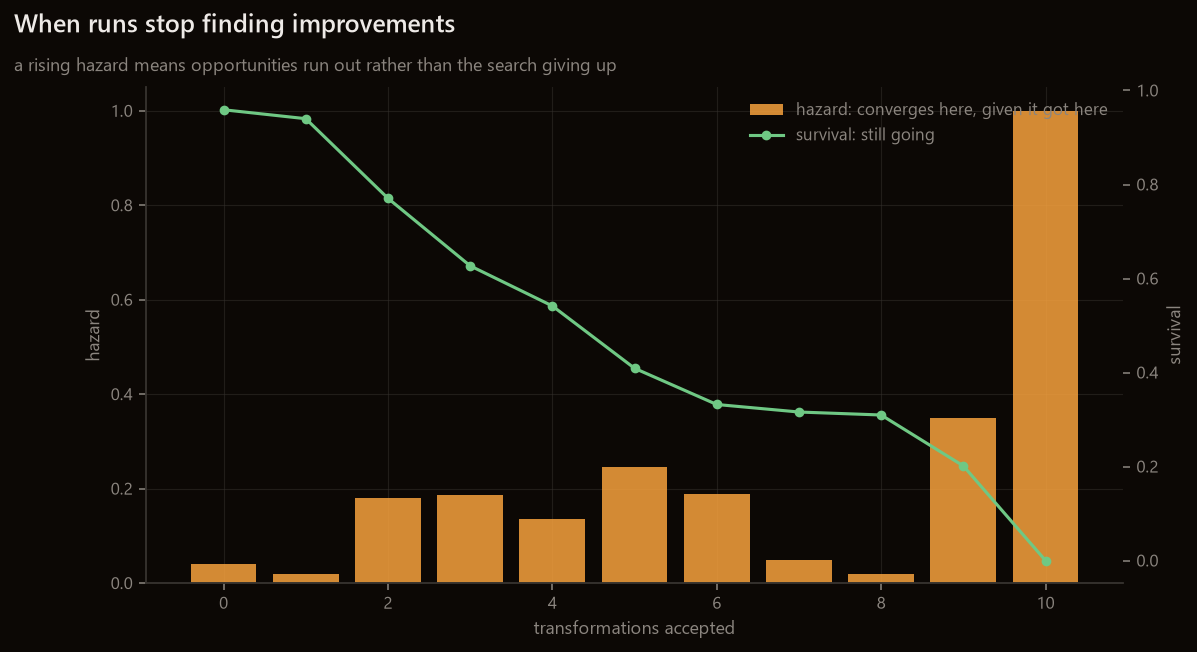

In [40]:
fig = statfigs.hazard_curve(m7.tables["hazard"], THEME); plt.show()

## Reproducing this

    make corpus       generate the 500 programs
    make experiment   run the grid, producing the master CSV
    make mutants      inject faults, measure what each channel catches
    make analyze      run every test in this notebook
    make figures      the six required plots

Everything is seeded, and LLM responses are cached, so a rerun gives identical
numbers.